# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "vgg19-torch"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=33):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Experimental

In [3]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

device = torch.device("cuda:0")
model = models.vgg19().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = model.to(device)


### PyTorch (Baseline)

In [12]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
print(image.dtype)
image = image.to(device)
output = model(image)
grad = torch.randn_like(output)

df = pd.DataFrame()

baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=33, 
                                 measure_count=11)
#baseline_b = timeit("torch.autograd.grad(output_native, [image], grad, retain_graph=True)")
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch.float32
torch-native-gpu-forward:  [5.965953015468337, 5.733343292817924, 5.602221766656095, 5.613608991332127, 5.615261806683106, 5.6148819964040415, 5.615240866036126, 5.6148971515623005, 5.615641306521314, 5.615078420801597, 5.614710153278076]
5.656439887960095
torch-native-gpu-backward:  [5.857329618072871, 5.856023480494817, 5.85716420953924, 5.857044520477454, 5.857383691225992, 5.85648620670492, 5.8588267332225135, 5.856526959123033, 5.857576474998937, 5.858445709401911, 5.857377030858488]
5.857289512192744
        time      pass          item
0   5.656440   Forward  Torch Native
0   5.857290  Backward  Torch Native
0  11.513729      Full  Torch Native


In [5]:

model_dynamo = torch.compile(model, backend="inductor")

image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)

output = model_dynamo(image)
grad = torch.randn_like(output)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=111, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [5.376604729676031, 5.3194595232337445, 5.319156054709409, 5.319262477191719, 5.319677771547356, 5.330063637580957, 5.3401442311771286, 5.33946446638118, 5.339519154313985, 5.339951506136237, 5.339696525117835]
5.334818188824143
torch-dynamo-gpu-backward:  [10.529915189689344, 10.53035145138835, 10.530270577349642, 10.530024523603485, 10.530335383976364, 10.530603369949636, 10.530714205726309, 10.530493155054682, 10.530104206220523, 10.531177702317905, 10.531393626520225]
10.530489399254224
        time      pass          item
0   5.609047   Forward  Torch Native
0   5.837297  Backward  Torch Native
0  11.446344      Full  Torch Native
0   5.334818   Forward  Torch Dynamo
0  10.530489  Backward  Torch Dynamo
0  15.865308      Full  Torch Dynamo


In [6]:
df.style.hide(axis="index")

time,pass,item
5.609047,Forward,Torch Native
5.837297,Backward,Torch Native
11.446344,Full,Torch Native
5.334818,Forward,Torch Dynamo
10.530489,Backward,Torch Dynamo
15.865308,Full,Torch Dynamo


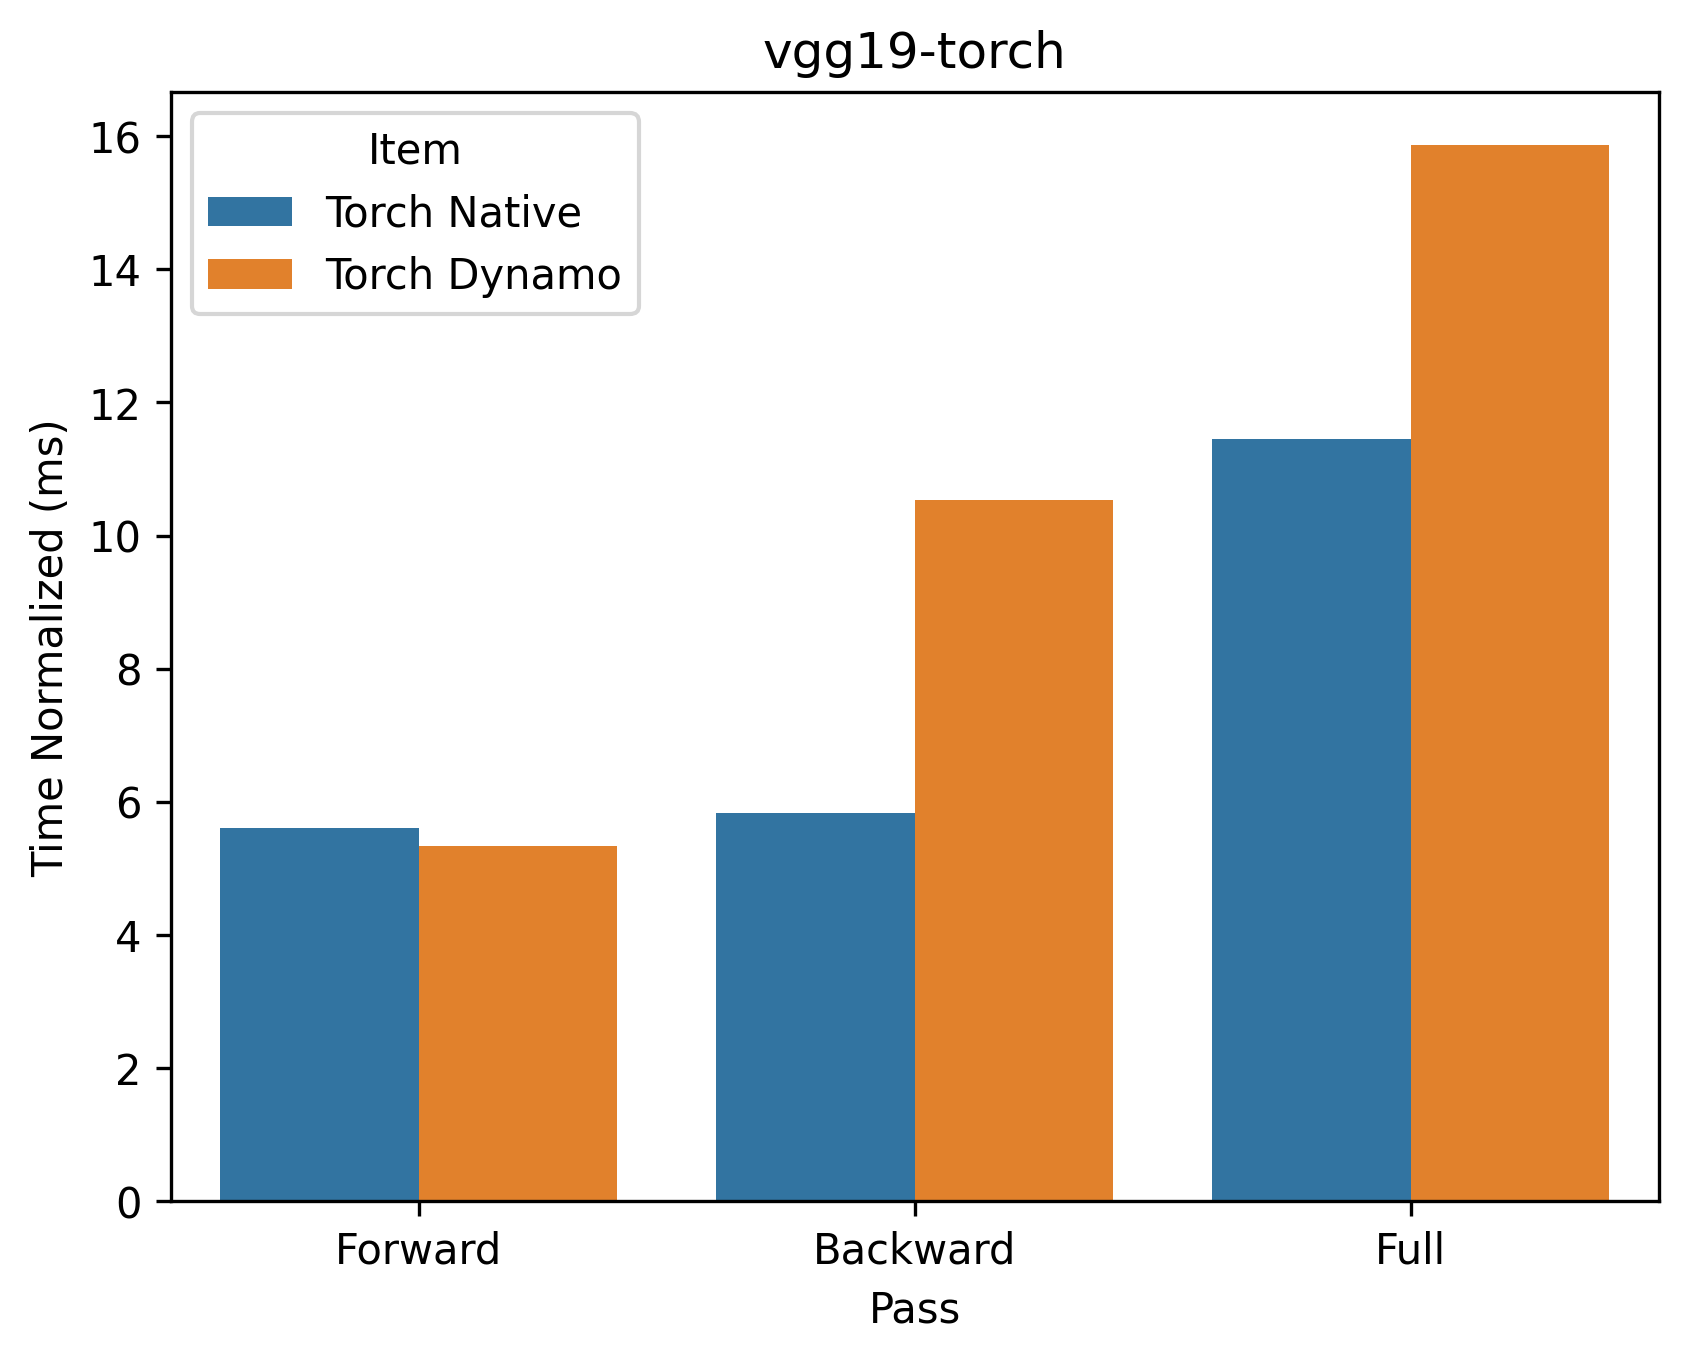

In [7]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [8]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,5.609047,Forward,Torch Native,0.95111
0,5.334818,Forward,Torch Dynamo,1.00000


In [9]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,5.837297,Backward,Torch Native,1.804001
0,10.530489,Backward,Torch Dynamo,1.000000


In [10]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,11.446344,Full,Torch Native,1.386059
0,15.865308,Full,Torch Dynamo,1.000000


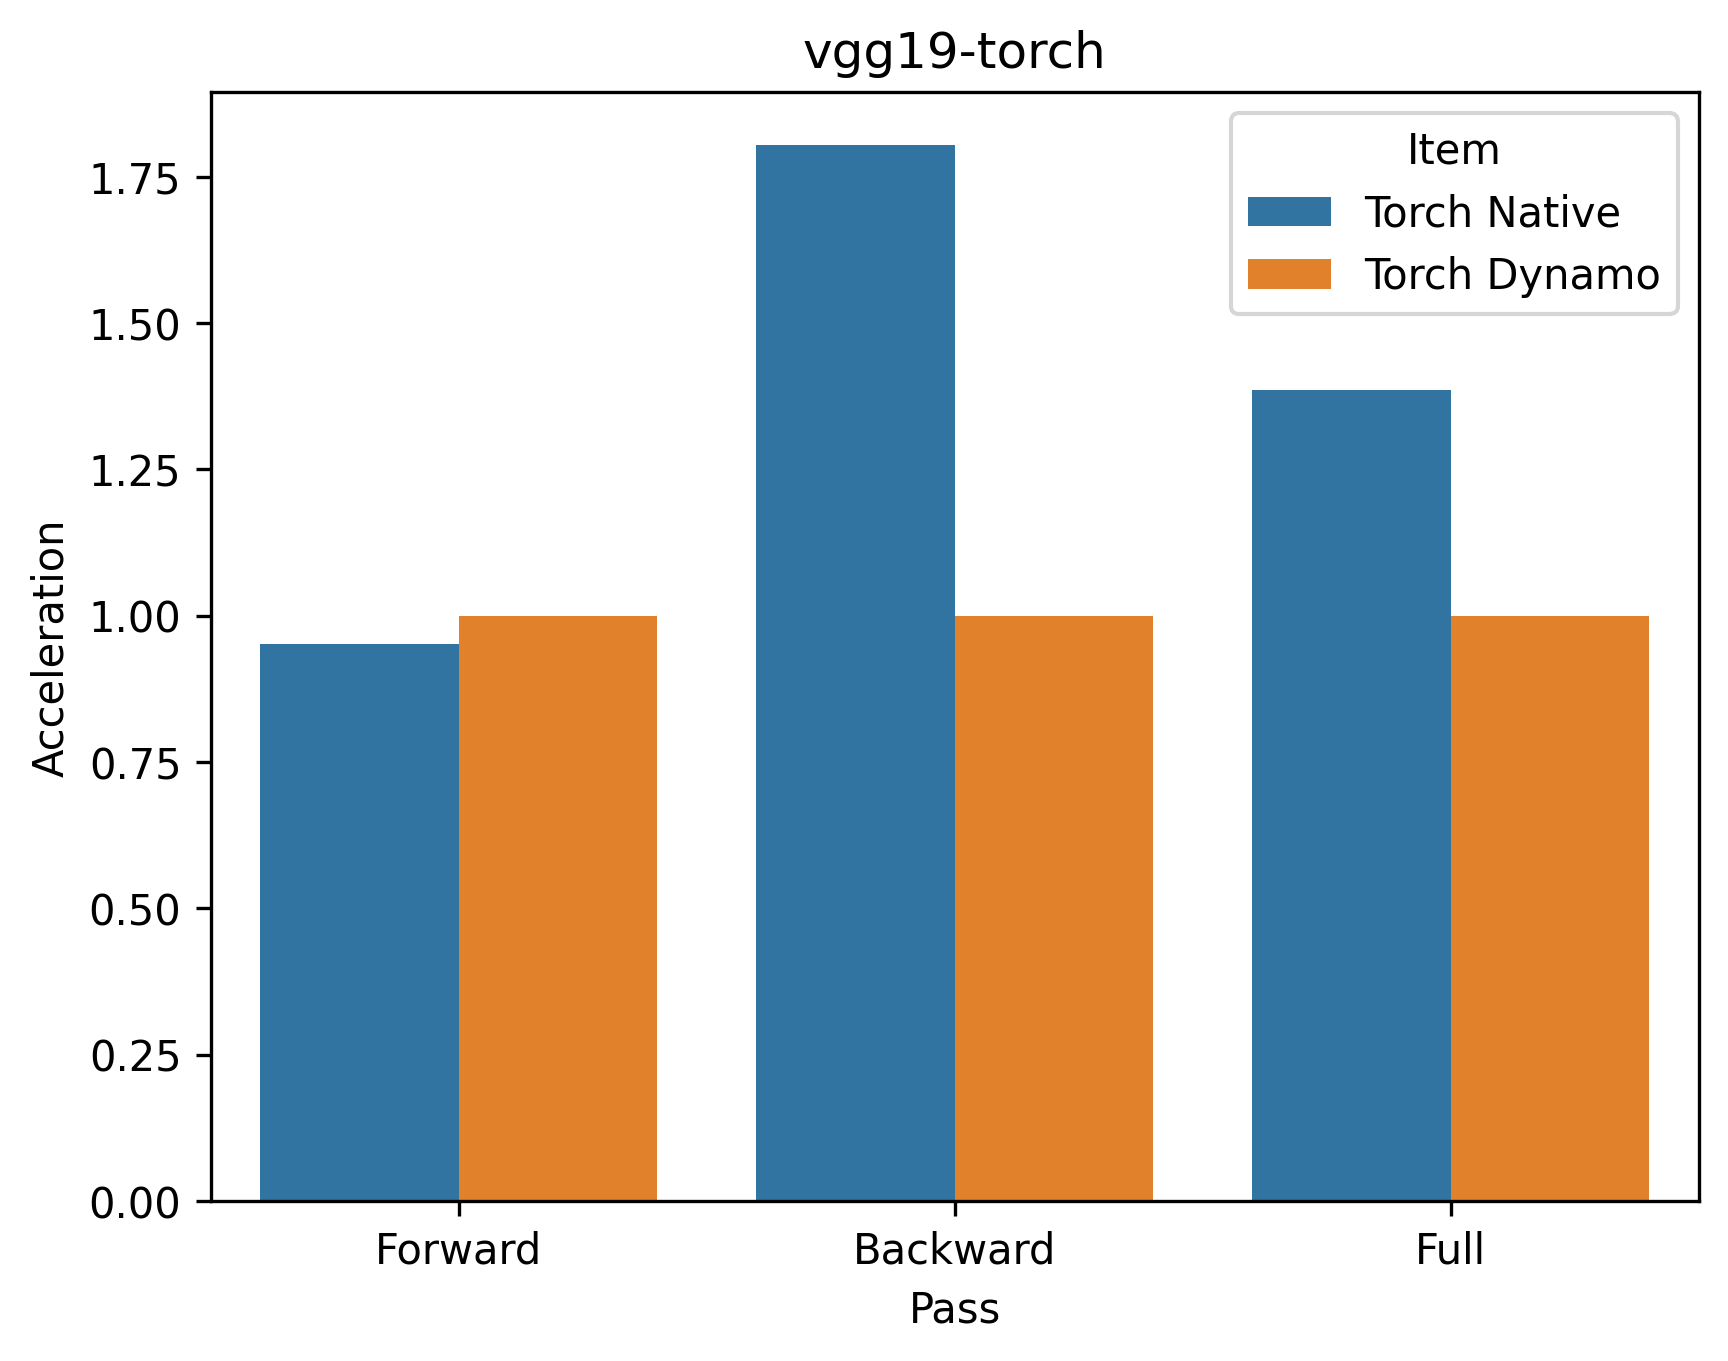

In [11]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")